# 📏 Metricas de Generacion en RAG
### Clase 03 — Boletin Oficial de Salta · Diplomatura IA · UBA

---

## De que trata este notebook

En un sistema RAG hay **dos etapas** que se pueden medir por separado:

```
QUERY  ->  [RETRIEVAL]  ->  chunks recuperados  ->  [GENERACION]  ->  RESPUESTA
               ↑                                         ↑
        Cuanto sirve lo                           Que tan fiel es
        que recuperamos?                          la respuesta al contexto?
```

Este notebook se enfoca **solo en la etapa de generacion** y mide dos cosas:

| # | Metrica | Pregunta central |
|---|---|---|
| 1 | **Token Overlap** | La respuesta generada contiene los terminos correctos? |
| 2 | **Context Faithfulness** | La respuesta sale del contexto o el LLM invento algo? |

Vamos a comparar un RAG **naive** (chunks sin estructura) contra un RAG **mejorado** (chunks con metadatos) usando el **mismo LLM** en ambos casos.  
Si el LLM es identico, la diferencia en las metricas viene 100% del contexto que le damos.


---
## Paso 1 — Instalacion


In [1]:
!pip install -q scikit-learn matplotlib pandas requests


In [2]:
import re, subprocess, threading, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests as req
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Colores del notebook
ROJO  = '#EF4444'   # naive
TEAL  = '#0D9488'   # mejorado

print('OK')


OK


---
## Paso 2 — Corpus

Usamos 6 documentos del Boletin Oficial de Salta (Ed. 21.922).  
Cada documento es un diccionario simple con el texto y sus metadatos.


In [3]:
# 6 documentos como dicts planos
DOCS = [
  {'op': 'SA100050325', 'tipo': 'ley',     'n': '8488', 'texto': (
   'LEY N 8488. ARTICULO 1.- Los cursos en materia de salud o educacion en Salta '
   'deben estar autorizados, homologados o certificados por Autoridades Provinciales '
   'o Nacionales competentes para su validez. '
   'ARTICULO 2.- La Autoridad de Aplicacion habilitara canales para verificar '
   'si la oferta educativa esta certificada. '
   'ARTICULO 3.- Los cursos que infrinjan el articulo 1 seran suspendidos. La persona '
   'responsable sera pasible de: a) Apercibimiento. '
   'b) Multa de entre 50.000 y 100.000 unidades tributarias. '
   'ARTICULO 4.- El Poder Ejecutivo determina la Autoridad de Aplicacion. '
   'SAENZ - Fiore Vinuales - De los Rios Plaza - Lopez Morillo.')},

  {'op': 'SA100050311', 'tipo': 'decreto', 'n': '167', 'texto': (
   'DECRETO N 167. MINISTERIO DE GOBIERNO, DERECHOS HUMANOS Y TRABAJO. '
   'Expediente N 0030041-32996/2025-0. '
   'VISTO la solicitud del Escribano Bruno Jose Bocanera de otorgamiento de Registro Notarial. '
   'CONSIDERANDO: El Escribano Bocanera cumplio los 10 anos de adjuncion '
   'conforme Decreto Reglamentario N 2582/2000 de la Ley N 6486. '
   'El Colegio de Escribanos mediante Acta N 2595 del 6 de febrero de 2025 '
   'verifico el cumplimiento de las obligaciones legales y profesionales. '
   'ARTICULO 1.- Designase al Escribano Bruno Jose Bocanera D.N.I. N 31.904.457 '
   'como titular del Registro Notarial N 11 con asiento en la ciudad de Salta. '
   'ARTICULO 2.- Comuniquese, publiquese y archivese. '
   'SAENZ - Villada - Lopez Morillo.')},

  {'op': 'SA100050312', 'tipo': 'decreto', 'n': '168', 'texto': (
   'DECRETO N 168. MINISTERIO DE SEGURIDAD Y JUSTICIA. '
   'Expediente N 0140044-100275/2024-0. '
   'VISTO el pedido de Retiro Voluntario del Suboficial Principal '
   'Carlos Cristian Figueroa Rueda. '
   'CONSIDERANDO: Se encuentran acreditados los requisitos para el Retiro '
   'conforme el Convenio de Transferencia del Sistema Provincial de Prevision Social '
   'ratificado por Ley N 8128. Visado positivo de ANSES y Resolucion N 2060/2024. '
   'ARTICULO 1.- Disponese el Retiro Voluntario del Suboficial Principal '
   'Carlos Cristian Figueroa Rueda D.N.I. N 27.465.890 Clase 1979 '
   'Legajo Personal N 13818 Cuerpo Seguridad Escalafon General. '
   'ARTICULO 2.- Debera usar licencias anuales pendientes. '
   'SAENZ - Sola Usandivaras - Lopez Morillo.')},

  {'op': 'SA100050326', 'tipo': 'decreto', 'n': '188', 'texto': (
   'DECRETO N 188. MINISTERIO DE SEGURIDAD Y JUSTICIA. '
   'Expediente N 341-53161/2025. '
   'VISTO la renuncia de la Dra. Maria Veronica Saicha Ibanez al cargo de Secretaria de Justicia. '
   'ARTICULO 1.- Aceptase la renuncia de la Dra. Maria Veronica Saicha Ibanez '
   'DNI N 20.339.284 al cargo de Secretaria de Justicia a partir de la fecha, '
   'dandoseles las gracias por los servicios prestados. '
   'ARTICULO 2.- Comuniquese, publiquese y archivese. '
   'SAENZ - Sola Usandivaras - Lopez Morillo.')},

  {'op': 'SA100050295', 'tipo': 'decision_adm', 'n': '110', 'texto': (
   'DECISION ADMINISTRATIVA N 110. MINISTERIO DE EDUCACION, CULTURA, CIENCIA Y TECNOLOGIA. '
   'Expediente N 0120047-47559/2024-0. '
   'VISTO el pedido de afectacion de la Sra. Salazar Arce Carolina Marianela '
   'personal del Ministerio de Educacion al Concejo Deliberante de la Ciudad de Salta. '
   'CONSIDERANDO: La afectacion es una medida de excepcion y caracter transitorio '
   'admitida para tareas especificas, condicionada a las razones que la originaron. '
   'ARTICULO 1.- Autorizar la afectacion de la Sra. Salazar Arce Carolina Marianela '
   'D.N.I. N 30.221.491 al Concejo Deliberante de la Ciudad de Salta '
   'desde el 01 de enero de 2025 hasta el 31 de diciembre de 2025. '
   'ARTICULO 2.- Refrendado por la Ministra de Educacion. '
   'Demetropulos - Fiore Vinuales.')},

  {'op': 'SA100050314', 'tipo': 'decreto', 'n': '170', 'texto': (
   'DECRETO N 170. MINISTERIO DE SEGURIDAD Y JUSTICIA. '
   'Expediente N 0140044-140618/2024-0. '
   'VISTO el pedido de Retiro Voluntario del Suboficial Mayor '
   'Alberto del Milagro Bonifacio. '
   'CONSIDERANDO: Requisitos acreditados. Visado positivo de ANSES '
   'y Resolucion N 2173/2024 del Ministerio de Seguridad y Justicia. '
   'ARTICULO 1.- Disponese el Retiro Voluntario del Suboficial Mayor '
   'Alberto del Milagro Bonifacio D.N.I. N 25.122.446 '
   'Legajo Personal N 13403 Clase 1976 Cuerpo Seguridad Escalafon General. '
   'ARTICULO 2.- Debera usar licencias anuales pendientes. '
   'SAENZ - Sola Usandivaras - Lopez Morillo.')},
]

print(f'{len(DOCS)} documentos cargados')
for d in DOCS:
    print(f"  {d['op']}  {d['tipo']:14}  N {d['n']:4}  "
          f"{len(d['texto'].split()):3} palabras")


6 documentos cargados
  SA100050325  ley             N 8488   96 palabras
  SA100050311  decreto         N 167   106 palabras
  SA100050312  decreto         N 168    97 palabras
  SA100050326  decreto         N 188    73 palabras
  SA100050295  decision_adm    N 110   110 palabras
  SA100050314  decreto         N 170    81 palabras


---
## Paso 3 — Retrieval (simplificado)

El retrieval no es el foco de este notebook: usamos TF-IDF basico.  
Lo importante viene despues: **que contexto le llega al LLM**.

**Diferencia clave entre los dos sistemas:**

- **Naive**: chunks de texto plano sin saber a que documento pertenecen
- **Mejorado**: cada chunk lleva un prefijo `[DECRETO N 168 | OP: SA100050312]` que ayuda al LLM a ubicar la informacion


In [4]:
# ── Naive: concatenar todo y partir en trozos fijos ──────────────────────
def indexar_naive(docs, tam=100):
    texto_total = ' '.join(d['texto'] for d in docs)
    palabras    = texto_total.split()
    chunks = []
    for i in range(0, len(palabras), tam - 15):
        bloque = ' '.join(palabras[i : i + tam])
        if len(bloque.split()) >= 20:
            chunks.append({'texto': bloque, 'op': 'DESCONOCIDA', 'meta': ''})
    vec = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)
    mat = vec.fit_transform([c['texto'] for c in chunks])
    return chunks, vec, mat


# ── Mejorado: un chunk por doc + prefijo de contexto ─────────────────────
def indexar_mejorado(docs):
    chunks = []
    for d in docs:
        prefijo = f"[{d['tipo'].upper()} N {d['n']} | OP {d['op']}] "
        chunks.append({
            'texto':     d['texto'],          # texto limpio (para mostrar)
            'texto_idx': prefijo + d['texto'], # texto indexado (con contexto)
            'op':        d['op'],
            'meta':      prefijo,
        })
    vec = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)
    mat = vec.fit_transform([c['texto_idx'] for c in chunks])
    return chunks, vec, mat


def recuperar(query, chunks, vec, mat, k=2):
    sims = cosine_similarity(vec.transform([query]), mat).flatten()
    top  = sims.argsort()[::-1][:k]
    return [{**chunks[i], 'score': float(sims[i])} for i in top]


CH_N, VEC_N, MAT_N = indexar_naive(DOCS)
CH_M, VEC_M, MAT_M = indexar_mejorado(DOCS)

print(f'Indice naive:    {len(CH_N)} chunks (sin metadata)')
print(f'Indice mejorado: {len(CH_M)} chunks (1 por documento, con prefijo)')


Indice naive:    7 chunks (sin metadata)
Indice mejorado: 6 chunks (1 por documento, con prefijo)


---
## Paso 4 — LLM local con Ollama

Usamos **Ollama** para correr un LLM en la maquina sin API key ni costo.

```
Modelo:   qwen2:0.5b  (352 MB, corre en CPU)
Tiempo:   ~2-3 min la primera vez (descarga), luego instantaneo
Opcional: cambiar a llama3.2:1b (1.3 GB) para mejor calidad de respuesta
```

> El modelo es **identico** para los dos sistemas (naive y mejorado).  
> Cualquier diferencia en las metricas viene 100% del contexto que le pasamos.


In [26]:
import os
import subprocess
import threading
import time
import json
import requests as req

MODELO = 'qwen2:0.5b'  # o 'llama3.2:1b' para mejor calidad

print('[0/3] Instalando zstd...')
subprocess.run("sudo apt-get update && sudo apt-get install -y zstd", shell=True, capture_output=True, text=True)
print('OK zstd instalado.')

print('[1/3] Instalando Ollama...')
# Use sudo for installation to ensure proper permissions
install_command = "curl -fsSL https://ollama.com/install.sh | sudo sh"
r = subprocess.run(install_command, shell=True, capture_output=True, text=True)

if r.returncode != 0:
    print(f"ERROR: Ollama installation failed. Stderr: {r.stderr}")
    print(f"Stdout: {r.stdout}")
    raise RuntimeError("Ollama installation failed.") # Raise an error to stop execution
else:
    print('OK Ollama installed.')

# Define the full path to the ollama executable
OLLAMA_BIN = "/usr/local/bin/ollama"

print('[2/3] Iniciando servidor...')
def _serve():
    # Use the full path to ollama executable
    subprocess.run([OLLAMA_BIN, "serve"], capture_output=True)

threading.Thread(target=_serve, daemon=True).start()
time.sleep(4)

try:
    req.get("http://localhost:11434/api/tags", timeout=5)
    print("OK servidor activo")
except Exception as e:
    print(f"Server check failed first attempt: {e}. Retrying after 5 seconds...")
    time.sleep(5)
    try:
        req.get("http://localhost:11434/api/tags", timeout=5)
        print("OK servidor activo")
    except Exception as e:
        print(f"ERROR: Ollama server not active after retry. {e}")
        raise RuntimeError("Ollama server failed to start.") # Raise an error to stop execution

print(f'[3/3] Descargando {MODELO} (~352 MB)...')
# Use the full path to ollama executable
r2 = subprocess.run([OLLAMA_BIN, "pull", MODELO], capture_output=True, text=True)

if r2.returncode != 0:
    print(f"ERROR: Ollama model pull failed. Stderr: {r2.stderr[:200]}")
    print(f"Stdout: {r2.stdout}")
    raise RuntimeError(f"Failed to pull model {MODELO}.") # Raise an error
else:
    print('OK modelo listo')


[0/3] Instalando zstd...
OK zstd instalado.
[1/3] Instalando Ollama...
OK Ollama installed.
[2/3] Iniciando servidor...
OK servidor activo
[3/3] Descargando qwen2:0.5b (~352 MB)...
OK modelo listo


### Debugging `wget` download failure

The `wget` command failed with exit status 8. This means the download itself was unsuccessful. To understand why, let's run the `wget` command directly and inspect its output.

In [27]:
# Try downloading the Ollama binary directly with verbose output to diagnose the issue
import subprocess

ollama_temp_path = '/tmp/ollama_debug.ollama'

print(f"Attempting to download from https://ollama.com/download/ollama-linux-amd64 to {ollama_temp_path}")
r_wget_debug = subprocess.run(
    ['wget', '--verbose', 'https://ollama.com/download/ollama-linux-amd64', '-O', ollama_temp_path],
    capture_output=True, text=True
)

print(f"Wget command executed with return code: {r_wget_debug.returncode}")
if r_wget_debug.stdout:
    print("--- Wget STDOUT ---")
    print(r_wget_debug.stdout)
if r_wget_debug.stderr:
    print("--- Wget STDERR ---")
    print(r_wget_debug.stderr)

if r_wget_debug.returncode == 0 and os.path.exists(ollama_temp_path) and os.path.getsize(ollama_temp_path) > 0:
    print(f"Download successful! File saved to {ollama_temp_path}")
    print(f"File size: {os.path.getsize(ollama_temp_path)} bytes")
else:
    print("Download failed or file is empty/missing.")
    print("Please check the URL and your network connection.")


Attempting to download from https://ollama.com/download/ollama-linux-amd64 to /tmp/ollama_debug.ollama
Wget command executed with return code: 8
--- Wget STDERR ---
--2026-06-03 19:40:43--  https://ollama.com/download/ollama-linux-amd64
Resolving ollama.com (ollama.com)... 34.36.133.15
Connecting to ollama.com (ollama.com)|34.36.133.15|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64 [following]
--2026-06-03 19:40:43--  https://github.com/ollama/ollama/releases/latest/download/ollama-linux-amd64
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/ollama/ollama/releases/download/v0.30.3/ollama-linux-amd64 [following]
--2026-06-03 19:40:44--  https://github.com/ollama/ollama/releases/download/v0.30.3/ollama-linux-amd64
Reusin

### Obtener la URL de descarga más reciente de Ollama

El error `404 Not Found` en el `wget` anterior indica que la URL de redirección a una versión específica de Ollama (`v0.30.3`) ya no es válida. Para asegurarnos de descargar siempre la versión más reciente, podemos consultar la API de GitHub para obtener el `browser_download_url` del último lanzamiento para `linux-amd64`.

In [28]:
import subprocess
import json

# Get the latest release information from GitHub API
print("Fetching latest Ollama release info from GitHub API...")
r_github_api = subprocess.run(
    ['curl', '-s', 'https://api.github.com/repos/ollama/ollama/releases/latest'],
    capture_output=True, text=True, check=True
)

release_info = json.loads(r_github_api.stdout)

# Find the download URL for linux-amd64 asset (explicitly checking asset name)
latest_ollama_url_amd64 = None

print("Available assets in the latest release:")
for asset in release_info.get('assets', []):
    print(f"  - Name: {asset['name']}, URL: {asset['browser_download_url']}")
    if asset['name'] == 'ollama-linux-amd64.tar.zst': # Look for the exact binary name, including .tar.zst
        latest_ollama_url_amd64 = asset['browser_download_url']


if latest_ollama_url_amd64:
    print(f"Latest Ollama Linux AMD64 download URL identified: {latest_ollama_url_amd64}")
else:
    print("ERROR: Could not find the latest Ollama Linux AMD64 download URL (asset 'ollama-linux-amd64.tar.zst').")
    print("Please review the available assets printed above and potentially adjust the filtering logic.")

# This part is for information; the main installation cell will be updated in the next step.

Fetching latest Ollama release info from GitHub API...
Available assets in the latest release:
  - Name: install.ps1, URL: https://github.com/ollama/ollama/releases/download/v0.30.3/install.ps1
  - Name: install.sh, URL: https://github.com/ollama/ollama/releases/download/v0.30.3/install.sh
  - Name: ollama-darwin.tgz, URL: https://github.com/ollama/ollama/releases/download/v0.30.3/ollama-darwin.tgz
  - Name: Ollama-darwin.zip, URL: https://github.com/ollama/ollama/releases/download/v0.30.3/Ollama-darwin.zip
  - Name: ollama-linux-amd64-mlx.tar.zst, URL: https://github.com/ollama/ollama/releases/download/v0.30.3/ollama-linux-amd64-mlx.tar.zst
  - Name: ollama-linux-amd64-rocm.tar.zst, URL: https://github.com/ollama/ollama/releases/download/v0.30.3/ollama-linux-amd64-rocm.tar.zst
  - Name: ollama-linux-amd64.tar.zst, URL: https://github.com/ollama/ollama/releases/download/v0.30.3/ollama-linux-amd64.tar.zst
  - Name: ollama-linux-arm64-jetpack5.tar.zst, URL: https://github.com/ollama/olla

In [29]:
SYSTEM = (
    'Eres un asistente legal de la Provincia de Salta. '
    'Responde SOLO con informacion del CONTEXTO provisto. '
    'Si la respuesta no esta en el contexto, '
    'responde exactamente: Sin informacion en el contexto. '
    'Maximo 2 oraciones. Solo en espanol.'
)

def generar(contexto: str, pregunta: str) -> str:
    """Llama al LLM con el contexto y la pregunta. Devuelve la respuesta."""
    prompt = f'CONTEXTO:\n{contexto}\n\nPREGUNTA: {pregunta}\n\nRESPUESTA:'
    try:
        r = req.post('http://localhost:11434/api/generate',
                     json={'model': MODELO, 'prompt': prompt, 'system': SYSTEM,
                           'stream': False,
                           'options': {'temperature': 0.05, 'num_predict': 150}},
                     timeout=60)
        return r.json().get('response','').strip()
    except Exception as e:
        return f'[ERROR: {e}]'


# Test rapido
test = generar('La capital de Salta es la ciudad de Salta.', 'Cual es la capital de Salta?')
print(f'Test: "{test}"')


Test: "La capital de Salta es Salta."


---
## Paso 5 — Consultas y respuestas de referencia

Definimos 6 preguntas con su **respuesta esperada** (ground truth).  
Estas respuestas sirven de referencia para calcular las metricas.


In [30]:
CONSULTAS = [
    {'q': 'Cual es la sancion por dictar cursos no autorizados segun la Ley 8488?',
     'ref': 'apercibimiento multa 50000 100000 unidades tributarias',
     'op_ok': 'SA100050325'},

    {'q': 'Quien fue designado titular del Registro Notarial N 11?',
     'ref': 'Bruno Jose Bocanera DNI 31904457',
     'op_ok': 'SA100050311'},

    {'q': 'Que legajo tiene Carlos Cristian Figueroa Rueda?',
     'ref': 'Legajo Personal 13818 Cuerpo Seguridad Escalafon General',
     'op_ok': 'SA100050312'},

    {'q': 'Quien renuncio al cargo de Secretaria de Justicia?',
     'ref': 'Maria Veronica Saicha Ibanez DNI 20339284',
     'op_ok': 'SA100050326'},

    {'q': 'Hasta cuando dura la afectacion de Carolina Salazar Arce?',
     'ref': '31 diciembre 2025 mientras duren necesidades servicio',
     'op_ok': 'SA100050295'},

    {'q': 'Cual es el DNI del Suboficial Mayor Alberto del Milagro Bonifacio?',
     'ref': '25122446 Legajo 13403 Clase 1976',
     'op_ok': 'SA100050314'},
]

print(f'{len(CONSULTAS)} consultas cargadas con ground truth')


6 consultas cargadas con ground truth


---
## Paso 6 — Ejecutar el pipeline completo

Para cada consulta:
1. Recuperamos los 2 chunks mas similares (naive y mejorado)
2. Construimos el contexto
3. Llamamos al LLM con ese contexto
4. Guardamos la respuesta

> Tiempo estimado: 1-3 minutos en total (12 llamadas al LLM)


In [31]:
RESULTADOS = []

for item in CONSULTAS:
    q = item['q']
    print(f'>> {q[:65]}')

    # --- NAIVE ---
    chunks_n  = recuperar(q, CH_N, VEC_N, MAT_N, k=2)
    ctx_n     = '\n'.join(c['texto'] for c in chunks_n)
    resp_n    = generar(ctx_n, q)

    # --- MEJORADO ---
    chunks_m  = recuperar(q, CH_M, VEC_M, MAT_M, k=2)
    ctx_m     = '\n'.join(c['meta'] + c['texto'] for c in chunks_m)
    resp_m    = generar(ctx_m, q)

    RESULTADOS.append({
        'q':       q,
        'ref':     item['ref'],
        'op_ok':   item['op_ok'],
        # naive
        'chunks_n': chunks_n, 'ctx_n': ctx_n, 'resp_n': resp_n,
        # mejorado
        'chunks_m': chunks_m, 'ctx_m': ctx_m, 'resp_m': resp_m,
    })
    print(f'   Naive:    {resp_n[:75]}')
    print(f'   Mejorado: {resp_m[:75]}')
    print()

print('OK todas las respuestas generadas')


>> Cual es la sancion por dictar cursos no autorizados segun la Ley 
   Naive:    La sanción por dictar cursos no autorizados en Salta según la Ley N° 8488, 
   Mejorado: La sanción por dictar cursos no autorizados según la Ley N° 8488, en el cas

>> Quien fue designado titular del Registro Notarial N 11?
   Naive:    Bruno Jose Bocanera
   Mejorado: El Escribano Bruno Jose Bocanera de 10 años de adjunción.

>> Que legajo tiene Carlos Cristian Figueroa Rueda?
   Naive:    Carlos Cristian Figueroa Rueda tiene el Legajo Personal N 13818 Cuerpo Segu
   Mejorado: Carlos Cristian Figueroa Rueda tiene un legajo Personal Número 13818 Cuerpo

>> Quien renuncio al cargo de Secretaria de Justicia?
   Naive:    La Dra. Maria Veronica Saicha Ibanez renunció al cargo de Secretaria de Jus
   Mejorado: La Dra. Maria Veronica Saicha Ibanez renunció al cargo de Secretaria de Jus

>> Hasta cuando dura la afectacion de Carolina Salazar Arce?
   Naive:    La afectacion de Carolina Salazar Arce comenzó el 

---
## 🟡 Metrica 1 — Token Overlap

### Que mide

Compara los **terminos de la respuesta generada** contra los terminos de la **respuesta esperada** (ground truth).

```
                 tokens(respuesta) ∩ tokens(referencia)
Token Overlap =  ───────────────────────────────────────
                         tokens(referencia)
```

| Score | Interpretacion |
|---|---|
| 1.0 | La respuesta contiene todos los terminos clave esperados |
| 0.5 | Contiene la mitad de los terminos |
| 0.0 | No contiene ningun termino relevante |

### Por que sirve

Es un proxy de **Answer Correctness**: mide si el LLM encontro la informacion correcta, sin necesitar un LLM-juez externo.


In [32]:
STOP = {
    'de','la','el','en','y','a','los','las','del','se','que','por','con',
    'un','una','es','al','lo','su','le','fue','para','como','mas','si',
    'no','son','ya','o','e','n','al','desde','hasta','al','ha','han',
}

def tokens(texto):
    """Extrae tokens significativos (sin stopwords ni tokens cortos)."""
    return {
        t.lower().strip('.,;:-()[]"') for t in texto.split()
        if len(t) > 2 and t.lower() not in STOP
    }

def token_overlap(respuesta, referencia):
    """Fraccion de tokens de la referencia que aparecen en la respuesta."""
    r, ref = tokens(respuesta), tokens(referencia)
    if not ref:
        return 0.0
    return round(len(r & ref) / len(ref), 3)


# Calcular para cada consulta
for entry in RESULTADOS:
    entry['to_n'] = token_overlap(entry['resp_n'], entry['ref'])
    entry['to_m'] = token_overlap(entry['resp_m'], entry['ref'])

# Mostrar resultados
print(f'{'Consulta':<40} {'TO Naive':>9} {'TO Mejor':>9}')
print('-' * 60)
for e in RESULTADOS:
    marca = '' if e['to_m'] >= e['to_n'] else ' <'
    print(f"{e['q'][:40]:<40} {e['to_n']:>9.3f} {e['to_m']:>9.3f}{marca}")
print('-' * 60)
prom_n = round(sum(e['to_n'] for e in RESULTADOS) / len(RESULTADOS), 3)
prom_m = round(sum(e['to_m'] for e in RESULTADOS) / len(RESULTADOS), 3)
print(f"{'PROMEDIO':<40} {prom_n:>9.3f} {prom_m:>9.3f}")


Consulta                                  TO Naive  TO Mejor
------------------------------------------------------------
Cual es la sancion por dictar cursos no      0.333     0.500
Quien fue designado titular del Registro     0.600     0.600
Que legajo tiene Carlos Cristian Figuero     1.000     1.000
Quien renuncio al cargo de Secretaria de     0.667     0.667
Hasta cuando dura la afectacion de Carol     0.333     0.333
Cual es el DNI del Suboficial Mayor Albe     0.800     0.000 <
------------------------------------------------------------
PROMEDIO                                     0.622     0.517


---
## 🟠 Metrica 2 — Context Faithfulness

### Que mide

Compara los **terminos de la respuesta** contra los terminos del **contexto que recibio el LLM**.

```
                      tokens(respuesta) ∩ tokens(contexto)
Context Faithfulness = ──────────────────────────────────────
                               tokens(respuesta)
```

| Score | Interpretacion |
|---|---|
| 1.0 | Cada termino de la respuesta estaba en el contexto: sin alucinacion |
| 0.5 | La mitad de la respuesta viene del contexto |
| 0.0 | El LLM no uso el contexto: respuesta inventada |

### Por que sirve

Detecta **alucinaciones**: cuando el LLM genera informacion que **no esta en los chunks recuperados**.  
Un RAG con retrieval pobre devuelve chunks incorrectos -> el LLM no encuentra la respuesta en ellos -> inventa.


In [33]:
def context_faithfulness(respuesta, contexto):
    """Fraccion de tokens de la respuesta que estan en el contexto."""
    r, ctx = tokens(respuesta), tokens(contexto)
    if not r:
        return 0.0
    return round(len(r & ctx) / len(r), 3)


# Calcular para cada consulta
for entry in RESULTADOS:
    entry['cf_n'] = context_faithfulness(entry['resp_n'], entry['ctx_n'])
    entry['cf_m'] = context_faithfulness(entry['resp_m'], entry['ctx_m'])

# Mostrar resultados
print(f'{'Consulta':<40} {'CF Naive':>9} {'CF Mejor':>9}  Interpretacion')
print('-' * 75)
for e in RESULTADOS:
    interp = 'OK' if e['cf_m'] >= 0.7 else 'posible alucinacion'
    print(f"{e['q'][:40]:<40} {e['cf_n']:>9.3f} {e['cf_m']:>9.3f}  {interp}")
print('-' * 75)
cf_prom_n = round(sum(e['cf_n'] for e in RESULTADOS) / len(RESULTADOS), 3)
cf_prom_m = round(sum(e['cf_m'] for e in RESULTADOS) / len(RESULTADOS), 3)
print(f"{'PROMEDIO':<40} {cf_prom_n:>9.3f} {cf_prom_m:>9.3f}")


Consulta                                  CF Naive  CF Mejor  Interpretacion
---------------------------------------------------------------------------
Cual es la sancion por dictar cursos no      0.522     0.500  posible alucinacion
Quien fue designado titular del Registro     1.000     0.667  posible alucinacion
Que legajo tiene Carlos Cristian Figuero     0.917     0.846  OK
Quien renuncio al cargo de Secretaria de     0.867     0.889  OK
Hasta cuando dura la afectacion de Carol     0.875     0.875  OK
Cual es el DNI del Suboficial Mayor Albe     0.938     0.857  OK
---------------------------------------------------------------------------
PROMEDIO                                     0.853     0.772


---
## 📊 Resultado: comparacion visual

El grafico muestra las dos metricas para cada consulta.  
Rojo = naive · Teal = mejorado.


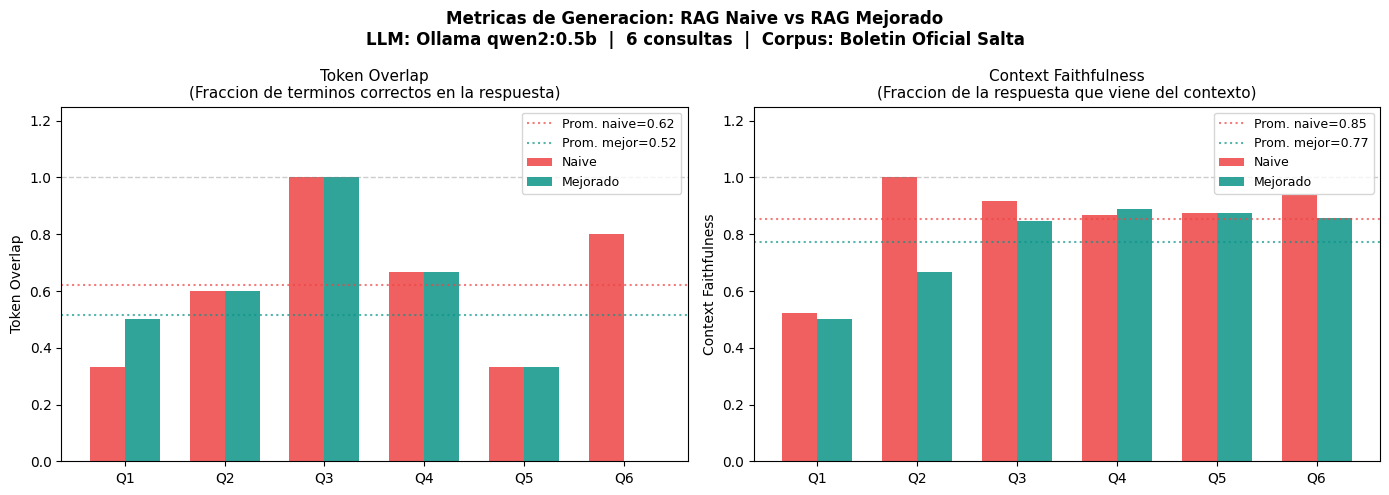

In [34]:
etiquetas = [f'Q{i+1}' for i in range(len(RESULTADOS))]
x = np.arange(len(RESULTADOS))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Metricas de Generacion: RAG Naive vs RAG Mejorado\n'
    f'LLM: Ollama {MODELO}  |  {len(RESULTADOS)} consultas  |  Corpus: Boletin Oficial Salta',
    fontweight='bold', fontsize=12
)

# ── Panel izquierdo: Token Overlap ──────────────────────────────────────────
ax = axes[0]
to_n_vals = [e['to_n'] for e in RESULTADOS]
to_m_vals = [e['to_m'] for e in RESULTADOS]
ax.bar(x - w/2, to_n_vals, w, color=ROJO, alpha=0.85, label='Naive')
ax.bar(x + w/2, to_m_vals, w, color=TEAL, alpha=0.85, label='Mejorado')
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.4)
ax.axhline(prom_n, color=ROJO, lw=1.5, ls=':', alpha=0.7, label=f'Prom. naive={prom_n:.2f}')
ax.axhline(prom_m, color=TEAL, lw=1.5, ls=':', alpha=0.7, label=f'Prom. mejor={prom_m:.2f}')
ax.set_title('Token Overlap\n(Fraccion de terminos correctos en la respuesta)',
             fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(etiquetas)
ax.set_ylabel('Token Overlap'); ax.set_ylim(0, 1.25)
ax.legend(fontsize=9)

# ── Panel derecho: Context Faithfulness ─────────────────────────────────────
ax = axes[1]
cf_n_vals = [e['cf_n'] for e in RESULTADOS]
cf_m_vals = [e['cf_m'] for e in RESULTADOS]
ax.bar(x - w/2, cf_n_vals, w, color=ROJO, alpha=0.85, label='Naive')
ax.bar(x + w/2, cf_m_vals, w, color=TEAL, alpha=0.85, label='Mejorado')
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.4)
ax.axhline(cf_prom_n, color=ROJO, lw=1.5, ls=':', alpha=0.7,
           label=f'Prom. naive={cf_prom_n:.2f}')
ax.axhline(cf_prom_m, color=TEAL, lw=1.5, ls=':', alpha=0.7,
           label=f'Prom. mejor={cf_prom_m:.2f}')
ax.set_title('Context Faithfulness\n(Fraccion de la respuesta que viene del contexto)',
             fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(etiquetas)
ax.set_ylabel('Context Faithfulness'); ax.set_ylim(0, 1.25)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('metricas_generacion.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
# ── Tabla resumen con las respuestas reales ──────────────────────────────
print('\n' + '='*70)
print('DETALLE DE RESPUESTAS')
print('='*70)
for i, e in enumerate(RESULTADOS, 1):
    print(f'\nQ{i}: {e["q"]}')
    print(f'   Referencia:  {e["ref"]}')
    print(f'   NAIVE    TO={e["to_n"]:.2f} CF={e["cf_n"]:.2f}  -> {e["resp_n"][:80]}')
    print(f'   MEJORADO TO={e["to_m"]:.2f} CF={e["cf_m"]:.2f}  -> {e["resp_m"][:80]}')

print('\n' + '='*70)
print('RESUMEN FINAL')
print('='*70)
print(f'  Metrica              Naive    Mejorado   Delta')
print(f'  Token Overlap        {prom_n:.3f}    {prom_m:.3f}      {prom_m-prom_n:+.3f}')
print(f'  Context Faithfulness {cf_prom_n:.3f}    {cf_prom_m:.3f}      {cf_prom_m-cf_prom_n:+.3f}')
print('='*70)
print()
print('LECTURA DE LOS RESULTADOS')
print()
print('Token Overlap mide si la respuesta contiene la informacion correcta.')
print('Un delta positivo significa que el RAG mejorado responde mejor.')
print()
print('Context Faithfulness mide si el LLM uso el contexto o alucino.')
print('Un delta positivo significa menos alucinacion en el RAG mejorado.')
print()
print('Conclusion: el mismo LLM, con mejor contexto, produce mejores respuestas.')
print('El retrieval no es un detalle de implementacion: es la calidad del RAG.')



DETALLE DE RESPUESTAS

Q1: Cual es la sancion por dictar cursos no autorizados segun la Ley 8488?
   Referencia:  apercibimiento multa 50000 100000 unidades tributarias
   NAIVE    TO=0.33 CF=0.52  -> La sanción por dictar cursos no autorizados en Salta según la Ley N° 8488, se ap
   MEJORADO TO=0.50 CF=0.50  -> La sanción por dictar cursos no autorizados según la Ley N° 8488, en el caso de 

Q2: Quien fue designado titular del Registro Notarial N 11?
   Referencia:  Bruno Jose Bocanera DNI 31904457
   NAIVE    TO=0.60 CF=1.00  -> Bruno Jose Bocanera
   MEJORADO TO=0.60 CF=0.67  -> El Escribano Bruno Jose Bocanera de 10 años de adjunción.

Q3: Que legajo tiene Carlos Cristian Figueroa Rueda?
   Referencia:  Legajo Personal 13818 Cuerpo Seguridad Escalafon General
   NAIVE    TO=1.00 CF=0.92  -> Carlos Cristian Figueroa Rueda tiene el Legajo Personal N 13818 Cuerpo Seguridad
   MEJORADO TO=1.00 CF=0.85  -> Carlos Cristian Figueroa Rueda tiene un legajo Personal Número 13818 Cuerpo Segu